In [1]:
import pandas as pd
import numpy as np
import nibabel as nib
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib as mpl

(np.float64(-0.5), np.float64(255.5), np.float64(0.5), np.float64(-0.5))

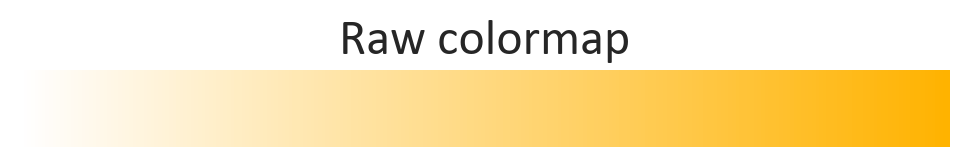

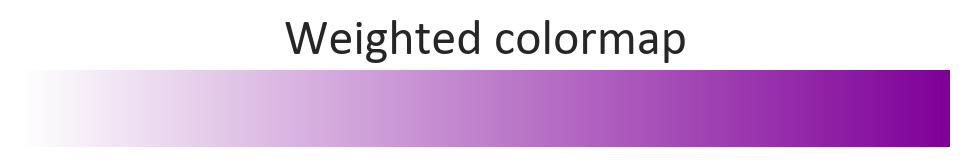

In [2]:
# ── Global visualisation configuration ──────────────────────────────────────

# 1.  General Matplotlib defaults
# ── Global visualisation configuration ──────────────────────────────────────
import matplotlib as mpl
import seaborn as sns

# Add font family to the rcParams (from tff file)
from matplotlib import font_manager

font_path = "/home/galkepler/.fonts/calibri-regular.ttf"
font_manager.fontManager.addfont(font_path)


mpl.rcParams.update(
    {
        # ── Canvas size & resolution ───────────────────────────────────────────
        # Default figure size: 12×8 inches  →  4800×3200 px when exported at 400 dpi
        "figure.figsize": (12, 8),
        "figure.dpi": 200,  # crisp in-notebook / retina preview
        "savefig.dpi": 400,  # print-quality PNG/PDF
        # ── Fonts ──────────────────────────────────────────────────────────────
        "font.family": "Calibri",
        # "font.sans-serif": ["Roboto", "DejaVu Sans", "Arial"],
        "font.sans-serif": ["Calibri", "DejaVu Sans", "Arial"],
        "axes.titlesize": 24,
        # "axes.titleweight": "bold",
        "axes.labelsize": 24,
        "xtick.labelsize": 14,
        "ytick.labelsize": 14,
        "legend.fontsize": 20,
        # ── Axis & spine aesthetics ────────────────────────────────────────────
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.spines.left": True,
        "axes.spines.bottom": True,
        "axes.linewidth": 1,
        "axes.grid": True,
        "grid.color": "#E6E6E6",
        "grid.linewidth": 0.4,
        "grid.alpha": 0.8,
        # ── Colour cycle (colour-blind-safe) ───────────────────────────────────
        "axes.prop_cycle": mpl.cycler(color=sns.color_palette("Set2")),
        # ── Figure background ─────────────────────────────────────────────────
        "figure.facecolor": "white",
    }
)

# Seaborn theme inherits the rcParams above
sns.set_theme(context="talk", style="whitegrid", palette="Set2")


# 2.  Seaborn theme (inherits Matplotlib rcParams)
sns.set_theme(
    context="talk",  # slightly larger fonts for presentations / papers
    style="whitegrid",  # grid only on y-axis (good for histograms)
    palette="Set2",  # matches the rcParams colour cycle
)


# 3.  Helper function for consistent figure export
def savefig_nice(fig, filename, *, tight=True, dpi=300, **savefig_kwargs):
    """Save figure with tight layout and correct DPI."""
    if tight:
        fig.tight_layout()
    fig.savefig(filename, dpi=dpi, bbox_inches="tight", transparent=True, **savefig_kwargs)


mpl.rcParams["font.family"] = "Calibri"  # or any other font you want

# 4.  Colour constants for this project (optional convenience)
# COL_RAW = "#1f77b4"  # e.g. unweighted sample
COL_RAW = "#ffb300"
# COL_WEIGHTED = "#d62728"  # weighted sample
COL_WEIGHTED = "#7F0099CE"  # weighted sample
COL_REF = "0.25"  # census reference (neutral grey)
COL_CENSUS = "#A5A5A5"

# generate colormaps from white to colour
COL_WHITE = "white"
COL_RAW_RGB = mpl.colors.to_rgb(COL_RAW)
COL_WEIGHTED_RGB = mpl.colors.to_rgb(COL_WEIGHTED)
CMAP_RAW = mpl.colors.LinearSegmentedColormap.from_list("raw", [COL_WHITE, COL_RAW_RGB], N=256)
CMAP_WEIGHTED = mpl.colors.LinearSegmentedColormap.from_list(
    "weighted", [COL_WHITE, COL_WEIGHTED_RGB], N=256
)
# visualize the colormaps
# if __name__ == "__main__":
fig, ax = plt.subplots(figsize=(6, 0.5))
ax.imshow(np.linspace(0, 1, 256)[None, :], aspect="auto", cmap=CMAP_RAW)
ax.set_title("Raw colormap")
ax.axis("off")
# savefig_nice(fig, "colormap_raw.png")

fig, ax = plt.subplots(figsize=(6, 0.5))
ax.imshow(np.linspace(0, 1, 256)[None, :], aspect="auto", cmap=CMAP_WEIGHTED)
ax.set_title("Weighted colormap")
ax.axis("off")
# savefig_nice(fig, "colormap_weighted.png")

In [3]:
def assign_weights_by_population(
    data: pd.DataFrame,
    population_df: pd.DataFrame,
    *,
    age_col: str = "age_at_scan",
    range_start: str = "range_start",
    range_end: str = "range_end",
    total: str = "total",
) -> np.ndarray:
    """
    Post-stratification weights so the age distribution of *data*
    matches an external reference.

    - Accepts integer or float ages.
    - Handles boundary ages (include_lowest=True).
    - Leaves bins with zero sample untouched (weight=0 → later dropped).
    - Returns weights whose mean == 1 across *non-zero* weights.
    """

    # 1. Make sure population bins are well-formed
    pop = (
        population_df[[range_start, range_end, total]]
        .sort_values(range_start)
        .reset_index(drop=True)
    )
    if (pop[range_end] <= pop[range_start]).any():
        raise ValueError("Each range_end must exceed range_start.")
    if (pop[range_start].iloc[1:].values < pop[range_end].iloc[:-1].values).any():
        raise ValueError("Age bins overlap or are not strictly increasing.")

    # 2. Bin edges for pd.cut  →  [..., last_end]  (right-inclusive)
    bin_edges = pop[range_start].tolist() + [pop[range_end].iloc[-1]]

    # Population proportions (works for % or counts)
    pop_prop = pop[total] / pop[total].sum()

    # 3. Assign each participant to a bin
    sample_bins = pd.cut(
        data[age_col],
        bins=bin_edges,
        right=True,  # include right edge
        include_lowest=True,  # include first left edge
        labels=pop.index,  # integer labels 0..n-1
    )

    # 4. Sample distribution
    sample_counts = sample_bins.value_counts(sort=False)
    sample_prop = sample_counts / sample_counts.sum()

    # 5. Weight lookup  (population / sample)  — careful with zeros
    weight_lookup = pop_prop / sample_prop.replace(0, np.nan)

    # 6. Map to rows; bins with zero sample → NaN weight → drop later
    w = sample_bins.map(weight_lookup).to_numpy()

    # Assign *zero* weight (instead of 1) to rows that were NaN
    w = np.where(np.isnan(w), 0.0, w)

    # 7. Rescale so mean(weight > 0) == 1
    positive = w > 0
    w[positive] = w[positive] / w[positive].mean()

    return w

In [5]:
import numpy as np
import pandas as pd


# ─────────────────────────────────────────────────────────────────────────────
def compute_poststrat_weights(
    sample_df: pd.DataFrame,
    pop_df: pd.DataFrame,
    *,
    age_col: str = "age_at_scan",
    start_col: str = "range_start",
    end_col: str = "range_end",
    pop_total_col: str = "total",
    cap: float | None = None,
    return_bin_table: bool = False,
):
    """
    Post-stratification weights so that the age distribution of *sample_df*
    matches an external population distribution supplied in *pop_df*.

    Parameters
    ----------
    sample_df : DataFrame with an ``age_col`` column (years; int or float).
    pop_df    : DataFrame with columns
                    [start_col, end_col, pop_total_col].
                * Values in ``pop_total_col`` can be counts **or** percentages
                  (they are internally re-scaled to proportions).
                * The row order doesn’t matter; they will be sorted.
    cap       : Optional float.  If provided, weights are truncated at
                ``cap × mean(weight)`` and then re-scaled so mean(weight)=1.
    return_bin_table : If True, also return a DataFrame summarising
                       n_sample, n_pop, and weight_factor for every bin.

    Returns
    -------
    weights   : 1-D numpy array aligned with ``sample_df.index``.
    bin_table : (optional) tidy per-bin summary (see above).
    """

    # 1 ── tidy & validate the population table --------------------------------
    pop = (
        pop_df[[start_col, end_col, pop_total_col]]
        .dropna()
        .astype({start_col: int, end_col: int, pop_total_col: float})
        .sort_values(start_col)  # your CSV is descending; fix that
        .reset_index(drop=True)
    )

    if (pop[end_col] <= pop[start_col]).any():
        raise ValueError("Each range_end must exceed range_start.")

    if (pop[start_col].iloc[1:].values < pop[end_col].iloc[:-1].values).any():
        overlap = pop.iloc[
            np.where(pop[start_col].iloc[1:].values < pop[end_col].iloc[:-1].values)[0] + 1
        ][[start_col, end_col]]
        raise ValueError(
            "Age bins overlap (rows shown below) — "
            "merge / correct them before weighting:\n"
            f"{overlap}"
        )

    # 2 ── build right-inclusive bin edges  (···| s_i  …  e_i | s_{i+1} …) ----
    edges = pop[start_col].tolist() + [pop[end_col].iloc[-1]]

    # 3 ── assign every participant to a bin -----------------------------------
    s_bins = pd.cut(
        sample_df[age_col],
        bins=edges,
        right=True,
        include_lowest=True,
        labels=pop.index,  # categorical labels 0,1,…
    )

    # 4 ── compute *sample* and *population* proportions per bin --------------
    n_sample = s_bins.value_counts(sort=False).sort_index()
    prop_sample = n_sample / n_sample.sum()

    prop_pop = pop[pop_total_col] / pop[pop_total_col].sum()

    # 5 ── weight factor = pop_prop / sample_prop ------------------------------
    weight_factor = prop_pop / prop_sample.replace(0, np.nan)  # avoid /0 → NaN

    # 6 ── map factor back to each row ----------------------------------------
    w = s_bins.map(weight_factor).astype(float).to_numpy()
    w = np.where(np.isnan(w), 0.0, w)  # rows that fell outside bins → 0

    # 7 ── optional weight truncation (winsorisation) --------------------------
    if cap is not None and cap > 0:
        mean_pos = w[w > 0].mean()
        w = np.clip(w, 0, cap * mean_pos)

    # 8 ── re-scale so mean(weight > 0) == 1 -----------------------------------
    positive = w > 0
    w[positive] = w[positive] / w[positive].mean()

    # 9 ── return --------------------------------------------------------------
    if return_bin_table:
        bin_tbl = pd.DataFrame(
            {
                "n_sample": n_sample,
                "n_pop": prop_pop * n_sample.sum(),  # rescaled to sample size
                "prop_sample": prop_sample,
                "prop_pop": prop_pop,
                "weight_factor": weight_factor,
            }
        )
        return w, bin_tbl

    return w

In [4]:
ATLAS = "schaefer2018tian2020_400_7"
region_col = "index"
# Load important files
DATA_DIR = Path("/media/storage/phd/neuroaging/data")

# Output directory for figures
OUTPUT_DIR = Path("/media/storage/phd/neuroaging/figures/revision/demographics")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Load the data
parcels = pd.read_csv(DATA_DIR / "external" / "atlases" / ATLAS / "parcels.csv", index_col=0)
nifti = DATA_DIR / "external" / "atlases" / ATLAS / "atlas.nii.gz"
nifti_matlab = DATA_DIR / "external" / "atlases" / ATLAS / "atlas_matlab.nii"

In [25]:
data_template = pd.read_csv(DATA_DIR / "processed" / "gm_vol.csv", index_col=0)

/tmp/ipykernel_1368003/1976401404.py:1: DtypeWarning: Columns (1,7,61,67,71,72,73,74,75,77,78,79,80,85,86,87,88,89,90,92,106,108,109,114,115,116,117,118,125,126,127) have mixed types. Specify dtype option on import or set low_memory=False.
  data_template = pd.read_csv(DATA_DIR / "processed" / "gm_vol.csv", index_col=0)


In [26]:
israel_population = pd.read_csv(DATA_DIR / "processed" / "israel_population.csv")

In [27]:
data_template["subject_code"] = data_template["subject_code"].astype(str).apply(lambda x: x.replace(" ", "").replace(".", "").replace("-", "").replace("_", "")).astype(str).str.zfill(4)
data_template = data_template.drop_duplicates(subset="subject_code", keep="first")
finished_subjects = data_template["subject_code"].unique().tolist()

demo_df = pd.read_csv("~/Downloads/linked_sessions.csv").drop_duplicates(subset="subject_code")
demo_df["subject_code"] = demo_df["subject_code"].astype(str).apply(lambda x: x.replace(" ", "").replace(".", "").replace("-", "").replace("_", "")).astype(str).str.zfill(4)
q_df = pd.read_csv("~/Downloads/Qcenter - IntegratedQ.csv")
q_df["subject_code"] = q_df["Subject Code"].astype(str).apply(lambda x: x.replace(" ", "").replace(".", "").replace("-", "").replace("_", "")).astype(str).str.zfill(4)

/tmp/ipykernel_1368003/3656416585.py:7: DtypeWarning: Columns (0,1,2,3,4,6,8,9,11,14,15,16,17,18,19,23,28,29,30,31,32,33,34,36,37,38,40,41,42,43,52,53,55,56,58,70,71,72,73,74,75,78,79,80,81,82,83,86,87,88,89,90,91,92,93,94,99,102,103,104,109,110,111,112,113,115,116,118,128) have mixed types. Specify dtype option on import or set low_memory=False.
  q_df = pd.read_csv("~/Downloads/Qcenter - IntegratedQ.csv")


In [28]:
# merge demo and q_df
demo = demo_df.merge(q_df[["subject_code","DominantHand","Weight (kg)","Height (cm)","SocioEconimic","Education","Salary","PsychometricScore","Alcohol","Smoking","SmokeFrequency(PerDay)"]], on="subject_code", 
# keep subjects even if they are missing in q_df
                    # how="left"
                    )
# keep only finished subjects
demo = demo[demo["subject_code"].isin(finished_subjects)].drop_duplicates(subset="subject_code")

In [29]:
demo["Salary"].notna().sum()

np.int64(2191)

In [30]:
import pandas as pd
import numpy as np

# --- 1. Pre-processing: Calculate BMI ---
# BMI = weight(kg) / [height(m)]^2
# Note: Height is in cm, so we divide by 100
demo['BMI'] = demo['Weight (kg)'] / ((demo['Height (cm)'] / 100) ** 2)

# --- 2. Setup Education Order ---
edu_order = [
    'Elementary', 'Partial high school', 'High school graduate', 
    'Post-secondary school', 'Academic undergraduate', 'Academic graduate'
]
demo['Education'] = pd.Categorical(demo['Education'], categories=edu_order, ordered=True)

# --- 3. Define Age Bins ---
bins = [18, 35, 60, 88]
labels = ['Young (18-35)', 'Middle (36-60)', 'Older (61-87)']
demo['AgeGroup'] = pd.cut(demo['Age@Scan'], bins=bins, labels=labels, right=False)

# --- 4. Updated Summary Function ---
def get_summary_comprehensive(data):
    # Calculate valid N for each metric
    total_n = len(data)
    n_female = (data['Gender'] == 'Female').sum()
    perc_female = (n_female / total_n) * 100
    
    n_edu = data['Education'].count()
    perc_edu = (n_edu / total_n) * 100
    
    n_salary = data['Salary'].count()
    perc_salary = (n_salary / total_n) * 100
    
    n_psycho = data['PsychometricScore'].count()
    perc_psycho = (n_psycho / total_n) * 100
    
    # New Metrics Valid N
    n_bmi = data['BMI'].count()
    perc_bmi = (n_bmi / total_n) * 100
    
    n_alcohol = data['Alcohol'].count()
    perc_alcohol = (n_alcohol / total_n) * 100

    # Core Dictionary
    stats = {
        'N (Total)': total_n,
        'Age Mean (SD)': f"{data['Age@Scan'].mean():.2f} ({data['Age@Scan'].std():.2f})",
        'Sex (N, % Female)': f"{n_female} ({perc_female:.1f}%)",
        
        # BMI Rows
        'BMI (n, %)': f"{n_bmi} ({perc_bmi:.1f}%)",
        'BMI Mean (SD)': f"{data['BMI'].mean():.2f} ({data['BMI'].std():.2f})" if n_bmi > 0 else "N/A",
        
        # Alcohol Rows
        'Alcohol (n, %)': f"{n_alcohol} ({perc_alcohol:.1f}%)",
        'Alcohol Drinks/Week Mean (SD)': f"{data['Alcohol'].mean():.2f} ({data['Alcohol'].std():.2f})" if n_alcohol > 0 else "N/A",
        
        # Salary Rows (thousands)
        'Salary (n, %)': f"{n_salary} ({perc_salary:.1f}%)",
        'Salary Mean (SD)': f"{(data['Salary']/1000).mean():.2f} ({(data['Salary']/1000).std():.2f})" if n_salary > 0 else "N/A",
        
        # Psychometric Score Rows
        'Psychometric (n, %)': f"{n_psycho} ({perc_psycho:.1f}%)",
        'Psychometric Mean (SD)': f"{data['PsychometricScore'].mean():.2f} ({data['PsychometricScore'].std():.2f})" if n_psycho > 0 else "N/A",
        
        # Education Header
        'Education (n, %)': f"{n_edu} ({perc_edu:.1f}%)"
    }
    
    # Categorical Education percentages
    edu_counts = data['Education'].value_counts(normalize=True) * 100
    for cat in edu_order:
        stats[f'  - {cat} (%)'] = f"{edu_counts.get(cat, 0):.1f}%"
        
    return pd.Series(stats)

# Generate and Finalize Table
summary_table = demo.groupby('AgeGroup', observed=False).apply(get_summary_comprehensive).T
summary_table['Total'] = get_summary_comprehensive(demo)

summary_table

/tmp/ipykernel_1368003/1785584716.py:78: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  summary_table = demo.groupby('AgeGroup', observed=False).apply(get_summary_comprehensive).T


AgeGroup,Young (18-35),Middle (36-60),Older (61-87),Total
N (Total),2091,627,78,2796
Age Mean (SD),26.50 (3.90),43.25 (6.17),67.47 (6.12),31.40 (10.33)
"Sex (N, % Female)",862 (41.2%),230 (36.7%),34 (43.6%),1126 (40.3%)
"BMI (n, %)",2017 (96.5%),618 (98.6%),78 (100.0%),2713 (97.0%)
BMI Mean (SD),24.01 (9.06),25.28 (4.15),26.23 (4.09),24.36 (8.11)
"Alcohol (n, %)",1692 (80.9%),516 (82.3%),69 (88.5%),2277 (81.4%)
Alcohol Drinks/Week Mean (SD),1.40 (1.47),1.51 (1.76),1.28 (1.51),1.42 (1.54)
"Salary (n, %)",1624 (77.7%),501 (79.9%),66 (84.6%),2191 (78.4%)
Salary Mean (SD),13.81 (16.61),22.07 (17.90),25.14 (22.12),16.04 (17.51)
"Psychometric (n, %)",1041 (49.8%),353 (56.3%),16 (20.5%),1410 (50.4%)


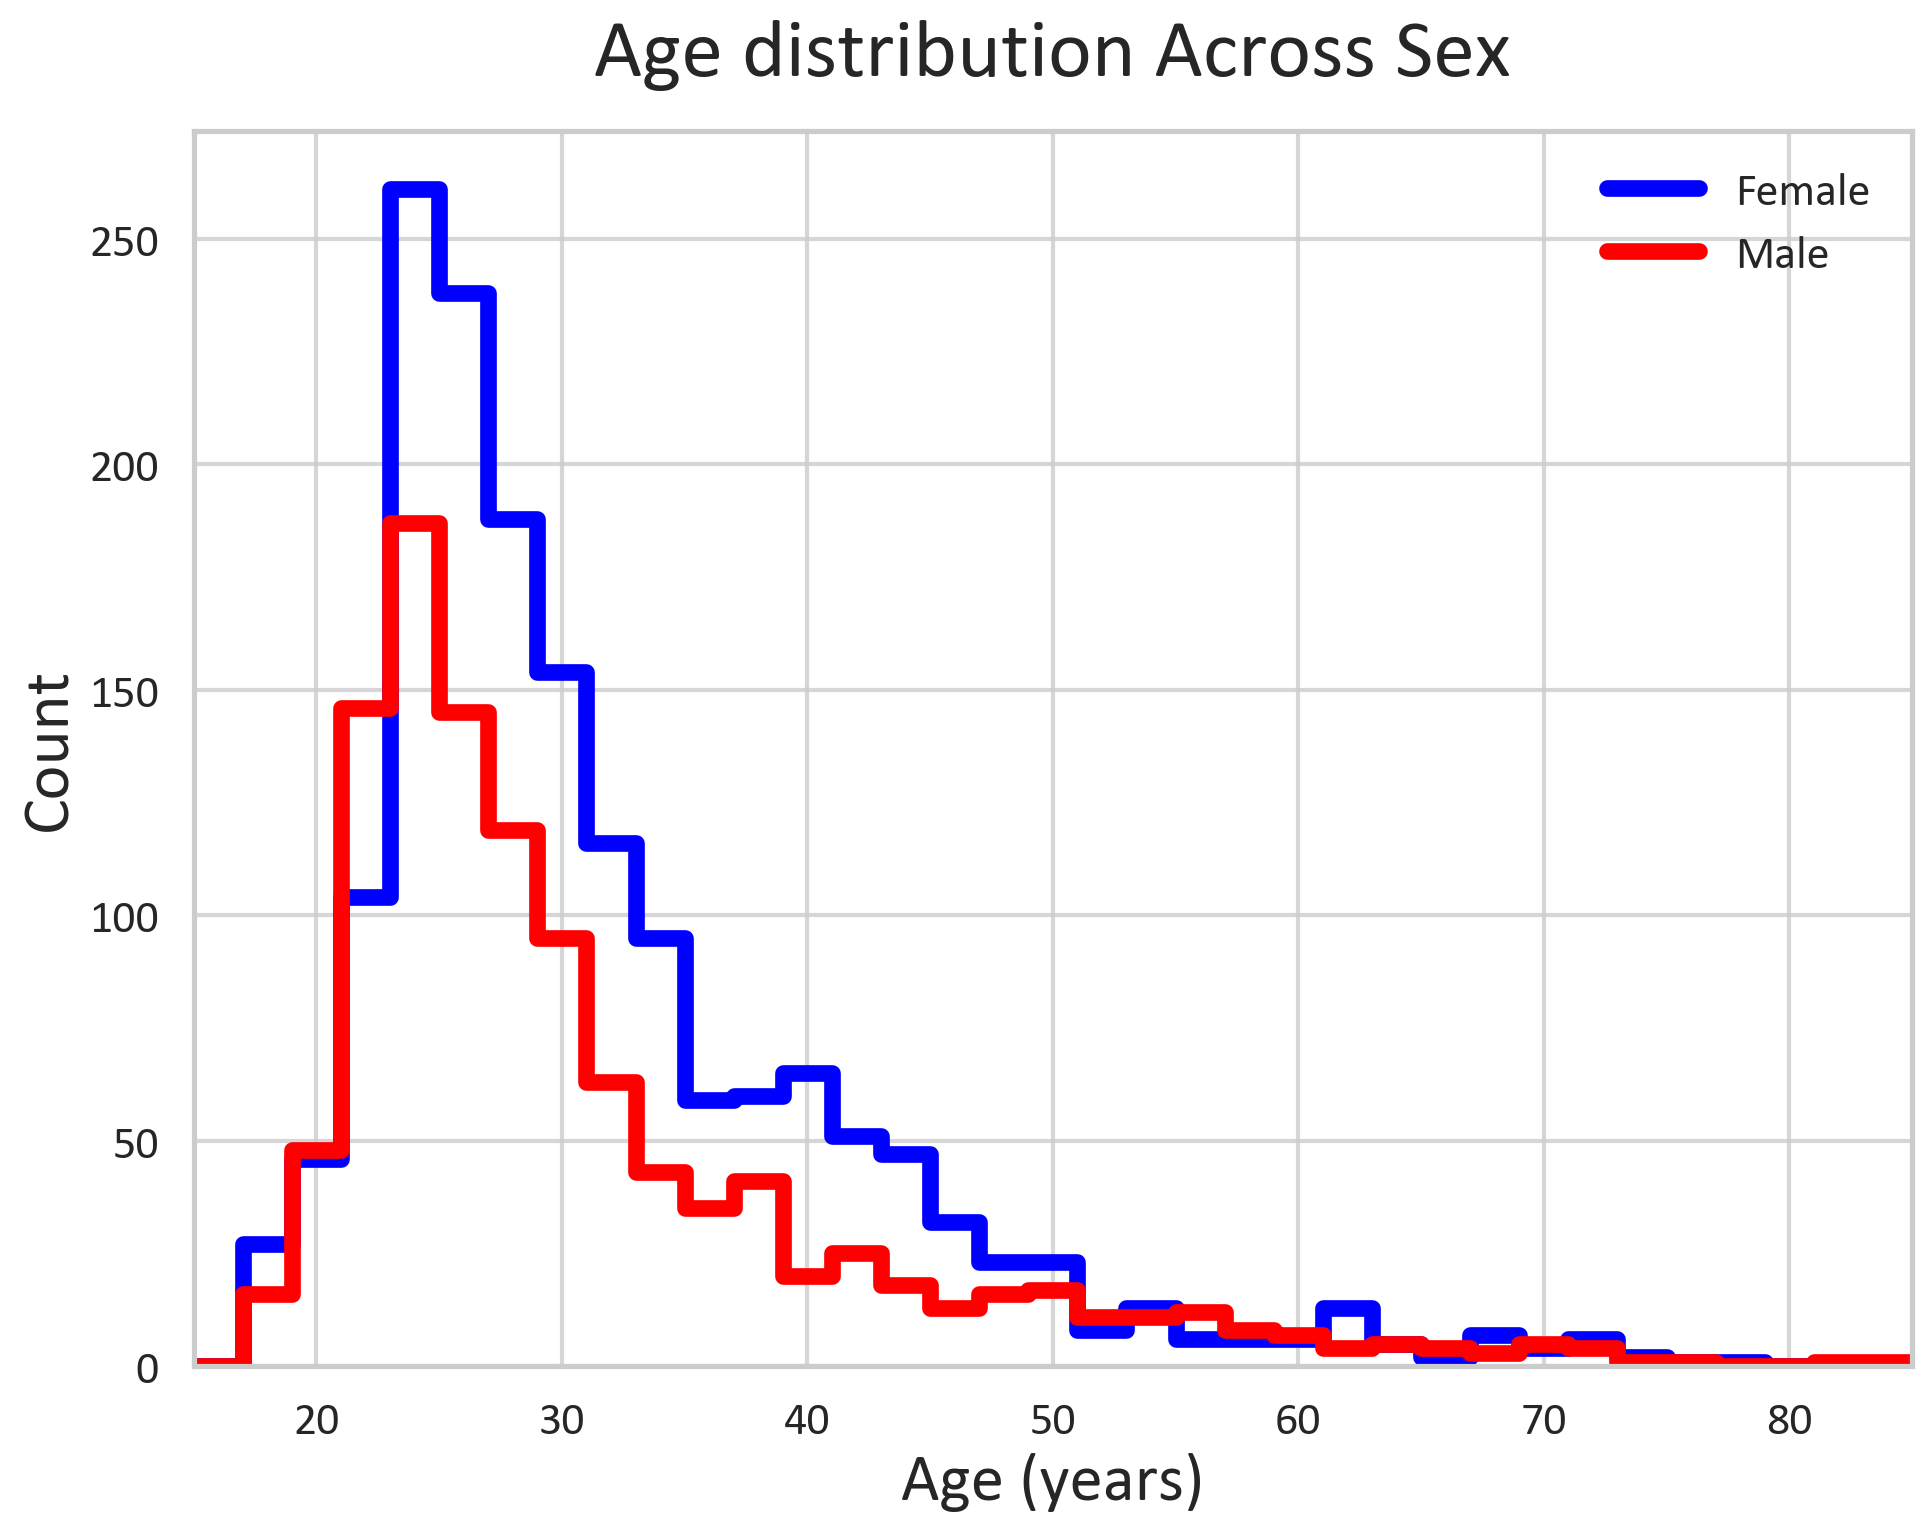

In [31]:
bin_width = 2  # years
age_min, age_max = 15, 85  # x-axis limits
line_width = 6
# ── figure canvas ─────────────────────────────────────────────────────────-
fig, ax = plt.subplots(figsize=(10, 8))

# ─────────────────────── Panel A: Age distribution ────────────────────────
bins = list(np.arange(age_min, age_max + bin_width, bin_width))  # ←  LIST


# Raw sample
ax = sns.histplot(
    demo,
    x="Age@Scan",
    hue="Gender",
    bins=bins,
    stat="count",
    element="step",
    fill=False,
    linewidth=line_width,
    palette={"Female": "red", "Male": "blue"},
    common_norm=False,
    ax=ax,
)

ax.set(xlim=(age_min, age_max))
ax.set_title("Age distribution Across Sex", fontsize=30, pad=20)
ax.set_ylabel("Count", fontsize=24)
ax.set_xlabel("Age (years)", fontsize=24)
# Legend is sex
ax.legend(labels=["Female", "Male"], frameon=False)

savefig_nice(
    fig,
    OUTPUT_DIR / "fig1b_age_distribution.png",
    tight=True,
    dpi=300,
)

In [119]:
OUTPUT_DIR

PosixPath('/media/storage/phd/neuroaging/figures/demographics')